# Tutorial: Classifier Accuracy
> Created Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> H. B. Prosper<br>


## Introduction

In the notebook `tutorial_2D_binary_classifier`, a simple classifier is built to classify the points in the 2D 2-Gaussian dataset. In this notebook we compare the approximate classifier to the exact one. The probability density of the multivariate normal is given by
\begin{align}
\mathcal{N}(x, \mu, \Sigma) & = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2} } \exp\left(-\tfrac{1}{2} z^T \Sigma^{-1} z \right) .
\end{align}
For a **bivariate normal**, ($d = 2$), we can write 
\begin{align}
    x & = \begin{bmatrix}
            x_1 \\ x_2
            \end{bmatrix}, \quad
    \mu  = \begin{bmatrix}
            \mu_1 \\ \mu_2
            \end{bmatrix}, \quad
    z  = \begin{bmatrix}
            x_1 - \mu_1 \\ x_2 - \mu_2
            \end{bmatrix},\\
    \Sigma & = \begin{bmatrix}
        \Sigma_{11} & \Sigma_{12}\\
        \Sigma_{21} & \Sigma_{22}
    \end{bmatrix}.
\end{align}
Therefore, in the notation of notebook `tutorial_2D_binary_classifier`, the exact classifier is given by
\begin{align}
    p(1 \mid x) & = \frac{p_1(x) \, \pi(1)}{m(x)},\quad\text{where} \nonumber\\
    p_j(x) & = \mathcal{N}(x, \mu^{(j)}, \Sigma^{(j)})\quad\text{and} \nonumber\\ 
    m(x) & = p_1(x)\, \pi(1) + p_0(x) \, (1 - \pi(1)),
\end{align}
with $\pi(1) = 1/2$ for a **balanced dataset**. The superscripts label the densities of the two classes of points.

In [1]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

import joblib
import importlib

import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat

# module for shell utilities
import shutil

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": shutil.which('latex') is not None, 
    "font.family": "sans-serif",
    "font.size": FONTSIZE
})

## Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

params_file = 'runs/gauss2d/gauss2d_params.pth'

Available device: cpu 


## Import exact density

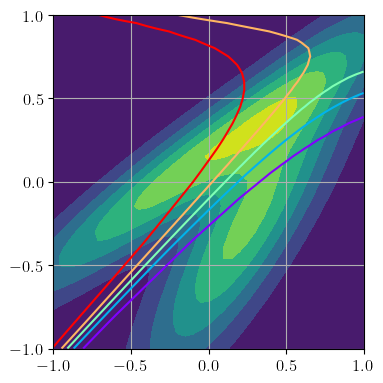

In [3]:
from exactdensity import ExactDensity

fexact = ExactDensity()
fexact.plot()

## Import model

In [4]:
import gauss2d
importlib.reload(gauss2d)

model = gauss2d.model
model.load(params_file)

print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
number of parameters 9


## Compute $C_\tfrac{1}{2} = p(1 \mid x)$ and $f_\widehat{\omega}(x)$

In [5]:
# Define a couple of one-line functions

# 1. flatten x1 and x2
# 2. stack column-wise
# 3. convert to 32-bit float
# 3. convert to tensor
flatten_x = lambda x1, x2: torch.tensor(
    np.stack([x1.flatten(), x2.flatten()], axis=1).astype(np.float32))

# 1. detach()   - detach from computational tree
# 2. cpu()      - move to CPU if tensor is not on a CPU, e.g., on GPU
# 3. numpy()    - convert to numpy array (ndarray)
fapprox = lambda x: model(x).detach().cpu().numpy()

In [6]:
# exact calculation
x1, x2 = fexact.grid()
pexact = fexact.prob(x1, x2)
print('pexact.shape\t', pexact.shape)

x = flatten_x(x1, x2)
print('x.shape \t', x.shape)

# reshape output of model to match that of pexact)
papprox = fapprox(x).reshape(pexact.shape)
print('papprox.shape\t', papprox.shape)

pexact.shape	 (41, 41)
x.shape 	 torch.Size([1681, 2])
papprox.shape	 (41, 41)


## Compare exact and approximate classifiers 

Compare contours of constant $C(x)$. The solid lines are the results of the exact calculation, while the dashed lines are computed using the model.

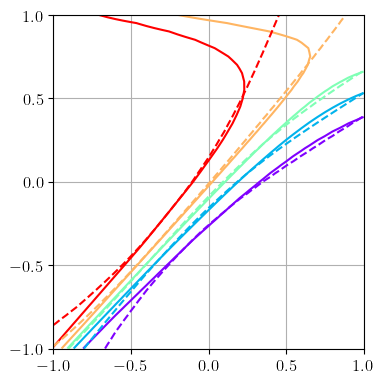

In [7]:
fexact.plot(papprox)

## Comparison of point clouds

Suppose that the prior for the class labeled $y = 1$ is $\pi$, then for a perfect classifier $C_\pi(x)$,
\begin{align}
    C_\pi(x) & = \frac{p_1(x) \, \pi}{m(x)},\\
    & = \frac{p_1(x)\, \pi}{p_1(x)\, \pi + p_0(x)\,(1-\pi)},\\
    & = \frac{{\color{blue}D(x)} \, \pi}{{\color{blue} D(x)}\, \pi + (1 - {\color{blue}D(x)})\,(1-\pi)},
\end{align}
where the discriminant $D(x) = C_{\tfrac{1}{2}}(x)$. It follows from the above that 
\begin{align}
    \mathbb{E}_{m(x)}[C_\pi] & = \pi .
\end{align}

Now suppose we draw a sample from the density $m(x) =  p_1(x)\, \pi + p_0(x)\,(1-\pi)$ and weight each point with a weight given by $w(x) = C_\pi(x)$. For a perfect classifier, this yields the function
\begin{align}
    p_w(x) & = w(x) \, m(x), \\
            & = \frac{p_1(x) \, \pi(1)}{m(x)} m(x),\\
            & = p_1(x) \, \pi(1).
\end{align}
This suggests another way to validate the classifier $C_\pi(x)$ or discriminant $D(x)$; weight $x \sim m(x)$ with $C_\pi(x)\, / \, \pi$ and compare two **point clouds**, one with $x \sim p_1(x)$ and the other containing weighted points. One might attempt the following:

  1. Bin the sample from class $y = 1$ in some sensible way. 
  3. Bin the weighted sample using the same bins.
  4. Compare the two sequences of counts.
  5. Devise ways to make useful statistical statements about the pair of sequences.

We'll explore the above in notebook `tutorial_point_clouds`.

### Exercises

  1. Write code that takes: $D(x) = \texttt{fapprox}(x)$, and the desired prior probability $0 \lt \pi < 1$ and computes,
     \begin{align}
    C_\pi(x) 
    & = \frac{{\color{blue}D(x)} \, \pi}{{\color{blue} D(x)}\, \pi + (1 - {\color{blue}D(x)})\,(1-\pi)} .
\end{align}

   2. Recall that \begin{align}
    \mathbb{E}_{m(x)}[C_\pi] & = \pi .
\end{align}
      Write code that takes: a sample drawn from $m(x)$, $D(x) = \texttt{fapprox}(x)$, and the desired prior probability $\pi$, and implements the average of $C_\pi(x)$ over the sample. Run your code for a sequence of values of the prior and compare with the formula above. You can use
```python
    import exactdensity as dn
            :     :
    fexact= dn.ExactDensity()
    rng   = np.random.default_rng(12345)
            :     :   
    total = 100_000
    prior = 0.1
    n1    = int(prior * total)
    n0    = total - n1
      
    x, y  = generate_data(n1, n0, rng)

```
      to generate the sample.

In [18]:
def generate_data(N1, N0, rng):
    # generate data and return as a numpy array
    data = fexact.generate(N1=N1, N0=N0, rng=rng)

    # convert to a dataset
    dataset = dat.Dataset(
        data, start=0, end=len(data), split_col=2, verbose=False)

    # create a loader for the dataset
    loader = dat.DataLoader(
        dataset, batch_size=len(dataset), verbose=False)
    
    return next(iter(loader))


rng  = np.random.default_rng(12345)
x, y = generate_data(10_000, 1000, rng)

x.shape, y.shape 

(torch.Size([11000, 2]), torch.Size([11000, 1]))